In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn.functional as F
from training.models.losses import ArcFaceLoss
from training.models.arcface import MetricLearningModel
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from evaluation.visualize import (
    plot_rejection_scores,
)
import gpytorch
from torch.utils.data import DataLoader
from utils_notebooks import predict_features, compute_distance_and_visualize
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.acquisition import LogExpectedImprovement

%load_ext autoreload
%autoreload 2

In [2]:
from toy_scf.models import (
    Backbone,
    train_arcface,
    compute_cosine_sim,
    predict_accuracy,
    load_arcface_model,
    load_scf_model,
    train_scf,
    compute_kappa,
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(size=112),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)
cifar_ds_train = datasets.CIFAR10(
    root="/app/datasets/cifar10", train=True, download=True, transform=transform
)
cifar_ds_test = datasets.CIFAR10(
    root="/app/datasets/cifar10", train=False, download=True, transform=transform
)
cifar_dl_train = DataLoader(
    cifar_ds_train,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=8,
)
cifar_dl_test = DataLoader(
    cifar_ds_test,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=8,
)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
from training.models.arcface import MetricLearningModel
from training.models.lightning_wrappers import ResNet
from training.models.losses import ArcFaceLoss

backbone = ResNet("iresnet18_normalized", False, True)
loss = ArcFaceLoss()
scheduler_params = {
    "scheduler": "OneCycleLR",
    "params": {
        "max_lr": 3e-2,
        "steps_per_epoch": 125,
        "epochs": 20,
        "div_factor": 1e1,
        "final_div_factor": 1e2,
    },
    "interval": "step",
    "frequency": 1,
}
model = MetricLearningModel(
    backbone=backbone,
    loss=loss,
    num_labels=10,
    num_features=512,
    scheduler_params=scheduler_params,
    weight_decay=5e-1,
)

/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
  rank_zero_warn(
/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
  rank_zero_warn(


In [6]:
from utils_notebooks import predict_features

model = model.load_from_checkpoint("/app/outputs/arcface_cifar10/base/last.ckpt")
predicted_features, image_labels = predict_features(model, cifar_dl_test)

  0%|          | 0/79 [00:00<?, ?it/s]/home/l.erlygin/miniconda/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
/home/l.erlygin/miniconda/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will chan

In [7]:
image_labels

array([3, 8, 8, ..., 5, 1, 7])

In [8]:
np.linalg.norm(predicted_features[2])

1.0000001

In [9]:
softmax_weights = model.softmax_weights.detach().cpu()
softmax_weights = F.normalize(softmax_weights, dim=1).numpy()

# dists = compute_distance_and_visualize(
#     predicted_features, image_labels, softmax_weights, num_features=512
# )
print(
    f"Test accuracy: {predict_accuracy(predicted_features, image_labels, softmax_weights)}"
)

Test accuracy: 0.5217


In [27]:
file_name = "full_cifar"
compute_cosine_sim(model, cifar_dl_train, cifar_dl_test, file_name)

  0%|          | 0/391 [00:00<?, ?it/s]/home/l.erlygin/miniconda/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
/home/l.erlygin/miniconda/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will cha

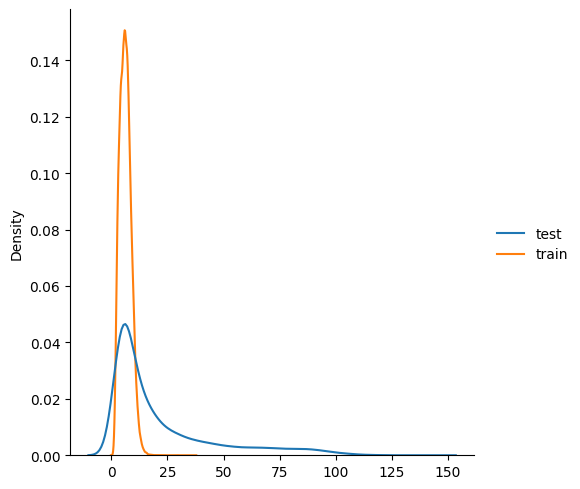

In [28]:
cosine_sim_train = np.load(f"outputs/train_{file_name}_cosine_sim.npy")
cosine_sim_test = np.load(f"outputs/test_{file_name}_cosine_sim.npy")
data = {
    "test": (np.arccos(cosine_sim_test) / (2 * np.pi)) * 360,
    "train": (np.arccos(cosine_sim_train) / (2 * np.pi)) * 360,
}
sns.displot(
    data,
    kind="kde",
    log_scale=False,
    common_norm=False,
)

In [32]:
np.sum((np.arccos(cosine_sim_train) / (2 * np.pi)) * 360 > 10), len(cosine_sim_train)

(3775, 50000)

In [14]:
softmax_weights.shape

(10, 512)